In [1]:
import gwsurrogate

/home/omkarnm1401/miniconda3/envs/ut_claude/lib/python3.11/site-packages/gwtools/const.py:52: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


In [2]:
import sys
# sys.path.append("/home/omkarnm1401/UT_Austin/BHPTutils")
# import bhpt_utils

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

In [5]:
from gwtools.gwtools import minimize_norm_error_multi_mode

In [6]:
# add the path to the script directory
#sys.path.append("/home/omkarnm1401/UT_Austin/BHPTNRSurrogate/surrogates")
import BHPTNRPNAnchored as bhptsur

In [7]:
sys.path.append("/home/omkarnm1401/UT_Austin/BHPTNRSurrogate/surrogates")
import BHPTNRSur1dq1e4 as bhptorigsur

/home/omkarnm1401/UT_Austin/BHPTNRSurrogate/surrogates/../data
**** Surrogate loaded: BHPTNRSur1dq1e4 ****


In [8]:
import matplotlib as mpl

sys.path.append("/home/omkarnm1401/UT_Austin/BHPTutils")
import bhpt_utils
mpl.rcdefaults()

In [9]:
plot_dir = 'Notebook_plots/'

In [10]:
nrsur = gwsurrogate.LoadSurrogate('NRHybSur3dq8')

Loaded NRHybSur3dq8 model


In [11]:
# convience wrapper for calling the NRHybSur3dq8 model
def generate_nrsur(q_input, f_low=None, t_start=None):
    chiA = [0, 0, 0.0]
    chiB = [0, 0, 0.0]
    dt = 0.1        # step size, Units of M
    if f_low==None:
        f_low=5e-3
    if t_start==None:
        t_start=-5000.1
    # dyn stands for dynamics and is always None for this model
    t, h, dyn = nrsur(q_input, chiA, chiB, dt=dt, f_low=f_low) 
    # we only take the last 5000M long waveform to calibrate
    indx = np.where(t>=t_start)
    t = t[indx]
    for mode in h.keys():
        h[mode] = h[mode][indx]
    return t,h

In [12]:
q_input = 2
mass_norm = 1/(1+1/q_input)

In [13]:
tnr, h_NRHybSur3dq8 = generate_nrsur(q_input=q_input)

In [14]:
nr_modes = list(h_NRHybSur3dq8.keys())
for mode in nr_modes:
    if mode[1] <=0: # m<=0; remove the (2,0) and (3,0) modes from NRHybSur3dq8 (these are not included in the BHPTNRSur1dq1e4 model)
        h_NRHybSur3dq8.pop(mode)
        
tbhpt, hbhpt = bhptsur.generate_pn_anchored_calibrated(q_input = q_input)

**** warning **** : input parameter is outside bounds for paramter value at index 0
**** warning **** : modes are NOT NR calibrated - waveforms only have 0PA contribution
Loaded NRSur3dq8Remnant fit.


In [15]:
h_NR_22 = h_NRHybSur3dq8[(2, 2)]

In [16]:
import gwtools

In [17]:
def mathcalE_error(h1, h2):
    """
    Compute time-domain waveform error.

    Calculates the normalized L2 error between two waveforms using the metric
    defined in Eq. 21 of https://arxiv.org/pdf/1701.00550.pdf

    Parameters:
    -----------
    h1 : array (complex)
        Reference waveform (used for normalization)
    h2 : array (complex)
        Comparison waveform (same length as h1)

    Returns:
    --------
    normed_errs : float
        Normalized error: (||h1||² + ||h2||² - 2*Re(<h1,h2>)) / (2*||h1||²)
        Value of 0 indicates perfect agreement, larger values indicate greater disagreement

    Notes:
    ------
    - Assumes h1 is the reference waveform and normalizes by its magnitude
    - Both waveforms should have the same time sampling
    - The metric is symmetric in the numerator but asymmetric due to normalization by ||h1||²
    """
    # Compute norms squared
    n1Sqr = np.sum(np.abs(h1)**2)
    n2Sqr = np.sum(np.abs(h2)**2)

    # Compute inner product
    dots = np.array([h1[i] * (h2[i].conjugate()) for i in range(len(h1))])
    sdot = np.real(np.sum(dots))

    # Normalize error by reference waveform magnitude
    normed_errs = ((n1Sqr + n2Sqr) - 2 * sdot) / (2 * n1Sqr)

    return normed_errs

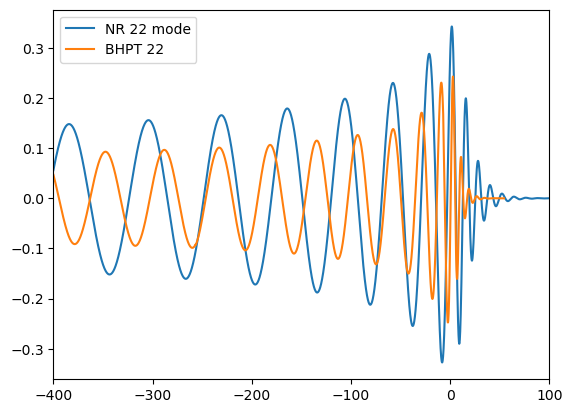

In [18]:
plt.plot(tnr, np.real(h_NR_22), label = 'NR 22 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt  * mass_norm), label = 'BHPT 22')

plt.xlim(-400, 100)
plt.legend()

In [20]:
h_nr_22 = {
    (2, 2): h_NRHybSur3dq8[(2, 2)]
}

h_bhpt_22 = {
    (2, 2): hbhpt[(2, 2)] if isinstance(hbhpt, dict) else hbhpt
}

[errors_before_min, errors_after_min], [tc, phic], [common_times, h_nr_aligned, h_bhpt_aligned] = \
    minimize_norm_error_multi_mode(
        tnr,
        h_nr_22,
        tbhpt,
        h_bhpt_22,
        mode_list=None,
        ell_m_match=(2, 2),
        t_low_adj=0,
        t_up_adj=0,
        method='nelder-mead'
    )

Performing a physical rotation by pi...


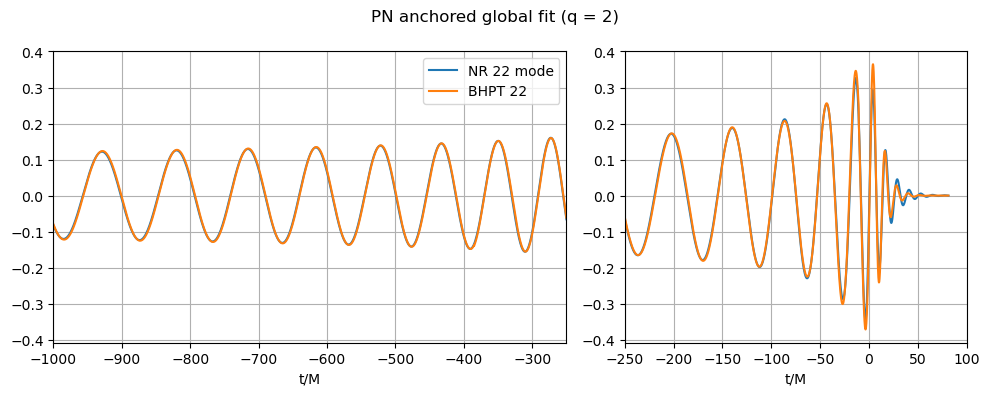

In [21]:
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [3, 2]}
)



ax1.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
ax1.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')

ax1.set_xlim(-1000, -250)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.legend()

ax2.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
ax2.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')
ax2.set_xlabel('t/M')

ax2.set_xlim(-250, 100)
ax2.grid(True)

plt.suptitle(f'PN anchored global fit (q = {q_input})')

plt.tight_layout()
#plt.savefig(plot_dir + 'Stricter_agentic_fit_physical_waveform_smooth.pdf')
plt.show()

In [22]:
mathcalE_error(h_bhpt_aligned[(2,2)], h_nr_aligned[(2,2)])

np.float64(0.0024153220329564554)

In [23]:
modes = [(2,2)]
ab = bhpt_utils.all_alpha_beta_1D_scaling_params(q_input, modes)
print(ab)

{'beta': 0.6239988070721827, 'alpha_l2m2': 0.6237143397920494}


In [24]:
t_param, alpha, beta = bhptsur.get_alpha_beta(q_input=q_input)

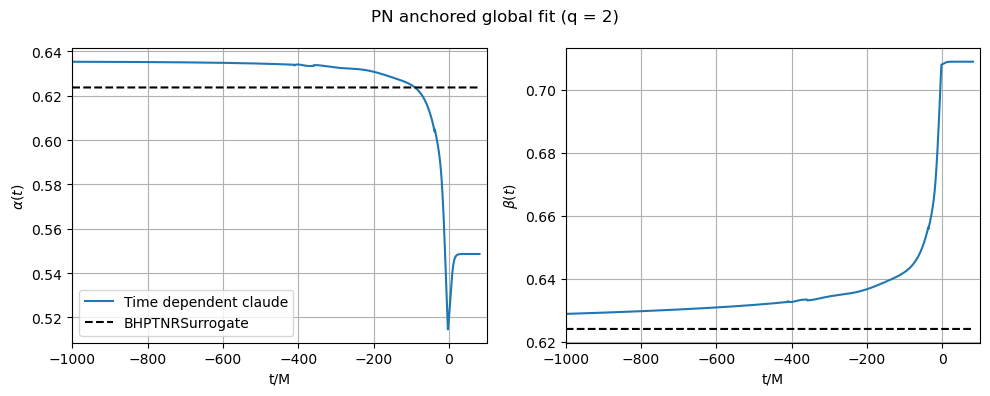

In [25]:
h_nr_22 = h_NRHybSur3dq8[(2, 2)]
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [2, 2]}
)



#ax1.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
ax1.plot(t_param, alpha, label = 'Time dependent claude')
ax1.plot(t_param, np.ones(len(t_param)) * ab['alpha_l2m2'], label = 'BHPTNRSurrogate', linestyle = 'dashed', color = 'k')

ax1.set_xlim(-1000, 100)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.set_ylabel(r'$\alpha(t)$')
ax1.legend()

#ax2.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
ax2.plot(t_param, beta)
ax2.plot(t_param, np.ones(len(t_param)) * ab['beta'], linestyle = 'dashed', color = 'k')
ax2.set_xlabel('t/M')
ax2.set_ylabel(r'$\beta(t)$')

ax2.set_xlim(-1000, 100)
ax2.grid(True)

plt.suptitle(f'PN anchored global fit (q = {q_input})')


plt.tight_layout()
#plt.savefig(plot_dir + 'Stricter_agentic_fit_physical_params_smooth.pdf')
plt.show()

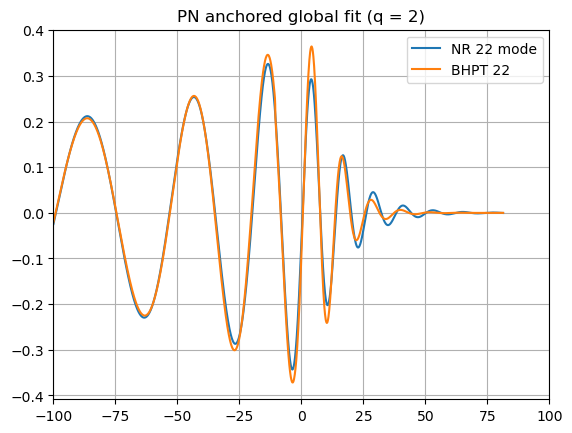

In [26]:
h_nr_22 = h_NRHybSur3dq8[(2, 2)]

plt.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
plt.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')

plt.xlim(-100, 100)
plt.title(f'PN anchored global fit (q = {q_input})')
plt.grid(True)

plt.legend()
#plt.savefig(plot_dir + 'Stricter_agentic_fit_physical_zoomed_smooth.pdf')
plt.show()

In [27]:
nr_modes = list(h_NRHybSur3dq8.keys())
for mode in nr_modes:
    if mode[1] <=0: # m<=0; remove the (2,0) and (3,0) modes from NRHybSur3dq8 (these are not included in the BHPTNRSur1dq1e4 model)
        h_NRHybSur3dq8.pop(mode)
        
tbhptcal, hbhptcal = bhptorigsur.generate_surrogate(q=q_input, modes=h_NRHybSur3dq8.keys(), calibrated=True, neg_modes=False)

**** warning **** : input parameter is outside bounds for paramter value at index 0


In [28]:
[errors_before_min, errors_after_min], [tc, phic], [common_times,h_bhpt_aligned,h_nr_aligned] = \
                            minimize_norm_error_multi_mode(tbhptcal, hbhptcal, tnr, h_NRHybSur3dq8, mode_list=None, ell_m_match=(2,2),\
                                    t_low_adj=0,t_up_adj=0,method='nelder-mead')

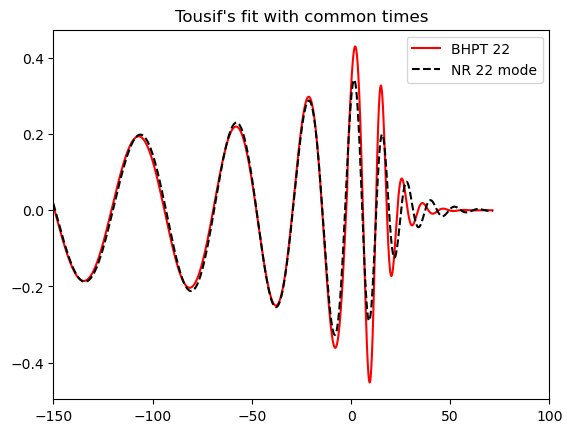

In [29]:
plt.plot(common_times, np.real(h_bhpt_aligned[(2,2)]), label = 'BHPT 22', color = 'red')
plt.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode', linestyle = 'dashed', color = 'k')

plt.xlim(-150, 100)
plt.legend()

plt.title("Tousif's fit with common times")
plt.show()

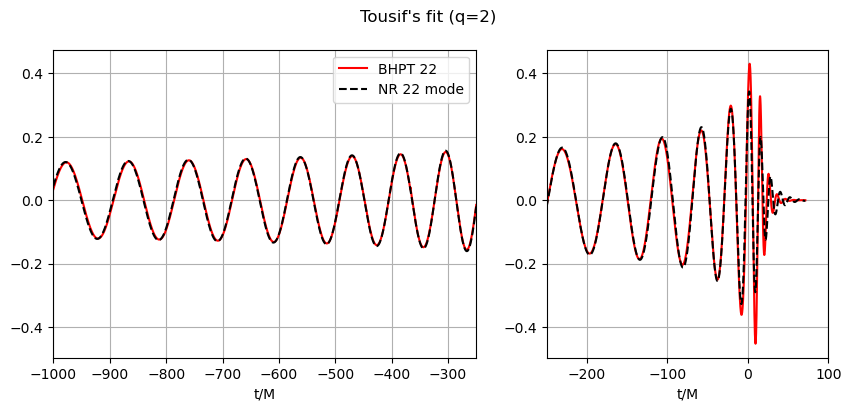

In [30]:
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [3, 2]}
)



ax1.plot(common_times, np.real(h_bhpt_aligned[(2,2)]), label = 'BHPT 22', color = 'red')
ax1.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode', linestyle = 'dashed', color = 'k')

ax1.set_xlim(-1000, -250)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.legend()

ax2.plot(common_times, np.real(h_bhpt_aligned[(2,2)]), label = 'BHPT 22', color = 'red')
ax2.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode', linestyle = 'dashed', color = 'k')
ax2.set_xlabel('t/M')

ax2.set_xlim(-250, 100)
ax2.grid(True)

#plt.tight_layout()
plt.suptitle(f"Tousif's fit (q={q_input})")
plt.show()

In [31]:
mathcalE_error(h_bhpt_aligned[(2,2)], h_nr_aligned[(2,2)])

np.float64(0.008599419634375242)